# House Price Prediction — Final Push to MAE ≤ 0.25

**Starting point:** MAE ≈ 0.447 (XGBoost + TargetEncoder, `model_selection.ipynb`)  
**Target:** MAE ≤ 0.25

## What this notebook fixes vs. previous attempts

| Problem | Fix |
|---|---|
| Raw `built_up_area` is skewed (outliers dominate) | `log_area`, `sqrt_area`, `area_sq` transforms |
| Coarse luxury bins lose numeric signal | Keep raw `luxury_score` as numeric feature alongside category |
| `floorNum` converted to 3 bins — loses real signal | Keep numeric `floorNum` alongside floor_category |
| TargetEncoder smoothing=0 overfits rare sectors | Use smoothing=10 |
| GridSearch too coarse / only Random Forest tuned | Optuna Bayesian search on XGBoost + LightGBM + CatBoost |
| Sector stats computed on full dataset (leakage in `mae_target_025.ipynb`) | Stats computed only on train fold |
| No stacking | 5-model stacking ensemble |
| `gurgaon_properties_post_feature_selection_v2.csv` dropped `floorNum`/`luxury_score` | Re-load from richer CSV (`gurgaon_properties_missing_value_imputation.csv`) |

## 0. Installs

In [1]:
import subprocess, sys
for pkg in ['xgboost', 'lightgbm', 'catboost', 'optuna', 'category_encoders']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)
print('Installs done.')

Installs done.


## 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import category_encoders as ce

from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
KFOLD_5  = KFold(n_splits=5,  shuffle=True, random_state=RANDOM_STATE)
KFOLD_10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

print('All libraries loaded.')

All libraries loaded.


## 2. Load Data

We use `gurgaon_properties_missing_value_imputation.csv` which still has
**numeric `floorNum`** and **numeric `luxury_score`** — both of which were
discarded too early in the original pipeline.

In [3]:
df_raw = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (3554, 18)
Columns: ['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession', 'built_up_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score']


,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3,2,2,2.0,New Property,850.0,0,0,0,0,0,1,8
1,flat,smart world gems,sector 89,0.95,8597.0,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,1,38
2,flat,breez global hill view,sohna road,0.32,5470.0,2,2,1,17.0,New Property,1000.0,0,0,0,0,0,1,49


## 3. Data Preparation

Keep raw numeric columns (`floorNum`, `luxury_score`) **and** their categorical
versions — both carry signal, especially for tree models.

In [4]:
df = df_raw.copy()

# Drop leaky / identifier columns
df = df.drop(columns=['society', 'price_per_sqft'], errors='ignore')

# Decode furnishing
df['furnishing_type'] = df['furnishing_type'].replace({
    0: 'unfurnished', 1: 'semifurnished', 2: 'furnished',
    0.0: 'unfurnished', 1.0: 'semifurnished', 2.0: 'furnished'
})

# Luxury category from luxury_score
def categorize_luxury(score):
    if score < 50:  return 'Low'
    elif score < 150: return 'Medium'
    else: return 'High'

df['luxury_category'] = df['luxury_score'].apply(categorize_luxury)

# Floor category from floorNum
def categorize_floor(floor):
    if floor <= 2:   return 'Low Floor'
    elif floor <= 10: return 'Mid Floor'
    else:             return 'High Floor'

df['floor_category'] = df['floorNum'].apply(categorize_floor)

print(f'Shape after prep: {df.shape}')
print(f'Price range: {df.price.min():.2f} — {df.price.max():.2f} Cr  |  mean={df.price.mean():.2f}')
df.head(3)

Shape after prep: (3554, 18)
Price range: 0.07 — 31.50 Cr  |  mean=2.44


,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 36,0.82,3,2,2,2.0,New Property,850.0,0,0,0,0,0,semifurnished,8,Low,Low Floor
1,flat,sector 89,0.95,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,semifurnished,38,Low,Mid Floor
2,flat,sohna road,0.32,2,2,1,17.0,New Property,1000.0,0,0,0,0,0,semifurnished,49,Low,High Floor


## 4. Feature Engineering

### Why each feature helps

| Feature | Rationale |
|---|---|
| `log_area`, `sqrt_area` | Compress right tail; luxury jump is captured by `area_sq` |
| `price_per_room_proxy` | Normalises area across flat/house segments |
| `bath_bed_ratio` | Detects premium layouts (≥ bathrooms = luxury signal) |
| `amenity_score` | Servant + store room combo is a strong luxury indicator |
| `area_bin` | Hard non-linearities at size boundaries (500→800→1200→2000) |

In [5]:
def engineer_features(df):
    df = df.copy()

    # Area transforms
    df['log_area']  = np.log1p(df['built_up_area'])
    df['sqrt_area'] = np.sqrt(df['built_up_area'])
    # FIX: area_sq (built_up_area^2) quadratically amplified outlier errors for large properties
    # Replaced with log_area_sq which captures non-linear area signal without amplifying outliers
    df['log_area_sq'] = df['log_area'] ** 2

    # Room ratios
    df['total_rooms']     = df['bedRoom'] + df['bathroom']
    df['bath_bed_ratio']  = df['bathroom'] / (df['bedRoom'] + 1e-6)
    df['area_per_room']   = df['built_up_area'] / (df['total_rooms'] + 1)

    # Amenity features
    df['has_servant']    = (df['servant room'] > 0).astype(int)
    df['has_store']      = (df['store room']   > 0).astype(int)
    df['amenity_score']  = df['has_servant'] + df['has_store']

    # FIX: Removed area_bin — arbitrary pd.cut boundaries create sharp discontinuities
    # that hurt tree models. Trees learn optimal split points from continuous built_up_area.

    return df

df_eng = engineer_features(df)
new_cols = [c for c in df_eng.columns if c not in df.columns]
print('New features:', new_cols)
print('Total features:', df_eng.shape[1] - 1)


## 5. Train / Test Split & Feature Groups

In [6]:
X = df_eng.drop(columns=['price'])
y = df_eng['price']
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)

# ---- Feature Groups ----
# FIX: Removed area_sq (quadratic outlier amplifier) and area_bin (redundant binning)
# Added log_area_sq as a safe non-linear area signal
NUM_COLS = [
    'bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room',
    'log_area', 'sqrt_area', 'log_area_sq',
    'total_rooms', 'bath_bed_ratio', 'area_per_room',
    'has_servant', 'has_store', 'amenity_score',
    'floorNum', 'luxury_score',
]
for col in ['study room', 'pooja room', 'others']:
    if col in X.columns:
        NUM_COLS.append(col)

ORD_COLS        = ['property_type', 'balcony', 'floor_category', 'luxury_category']
OHE_COLS        = ['agePossession', 'furnishing_type']   # FIX: removed area_bin
TARGET_ENC_COLS = ['sector']

all_used = set(NUM_COLS + ORD_COLS + OHE_COLS + TARGET_ENC_COLS)
missing  = all_used - set(X.columns)
if missing:
    print(f'WARNING — missing cols: {missing}')
    NUM_COLS = [c for c in NUM_COLS if c in X.columns]

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Numeric features : {len(NUM_COLS)}')
print(f'Ordinal features : {len(ORD_COLS)}')
print(f'OHE features     : {len(OHE_COLS)}')
print(f'Target-enc feat  : {len(TARGET_ENC_COLS)}')


## 6. Preprocessor Factory

In [7]:
def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('num',    StandardScaler(),
                   NUM_COLS),
        ('ord',    OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
                   ORD_COLS),
        ('ohe',    OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
                   OHE_COLS),
        # FIX: Increased smoothing from 10 to 100 to prevent rare sectors (<5 listings)
        # from being overfitted to their small empirical mean
        ('target', ce.TargetEncoder(smoothing=100),
                   TARGET_ENC_COLS),
    ], remainder='drop')

print('Preprocessor factory ready.')


## 7. Evaluation Helper

Back-transforms log predictions to Crores before computing all metrics.

In [8]:
all_results = []

def evaluate(name, pipeline, verbose=True):
    pipeline.fit(X_train, y_train)

    y_pred = np.expm1(pipeline.predict(X_test))
    y_true = np.expm1(y_test)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

    # 5-fold CV R² on training set
    cv_r2 = cross_val_score(
        pipeline, X_train, y_train, cv=KFOLD_5, scoring='r2', n_jobs=-1
    ).mean()

    if verbose:
        hit = ' *** TARGET HIT ***' if mae <= 0.25 else ('  < 0.30' if mae < 0.30 else '')
        print(f'{name:50s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.1f}%  CV_R²={cv_r2:.4f}{hit}')

    all_results.append({
        'name': name, 'mae': mae, 'rmse': rmse,
        'r2': r2, 'mape': mape, 'cv_r2': cv_r2,
        'pipeline': pipeline
    })
    return pipeline

print('evaluate() ready.')

evaluate() ready.


## 8. Baseline Models — Feature-Engineered Set

Quick run of all major algorithms to confirm FE improvements and pick best bases for tuning.

In [9]:
print('=== Baselines with Full Feature Engineering ===')
print(f'Previous best without FE+rich-data: MAE ≈ 0.447\n')

for name, model in [
    ('Extra Trees (200)',
     ExtraTreesRegressor(n_estimators=200, min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1)),
    ('Random Forest (200)',
     RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)),
    ('XGBoost default (300)',
     XGBRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
    ('LightGBM default (300)',
     lgb.LGBMRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
    ('CatBoost default (300)',
     CatBoostRegressor(iterations=300, random_state=RANDOM_STATE, verbose=0)),
]:
    pipe = Pipeline([('pre', make_preprocessor()), ('reg', model)])
    evaluate(name, pipe)

=== Baselines with Full Feature Engineering ===
Previous best without FE+rich-data: MAE ≈ 0.447

Extra Trees (200)                                   MAE=0.4633  RMSE=1.0385  R²=0.8597  MAPE=18.9%  CV_R²=0.8812
Random Forest (200)                                 MAE=0.4820  RMSE=1.0821  R²=0.8476  MAPE=19.7%  CV_R²=0.8835
XGBoost default (300)                               MAE=0.4675  RMSE=1.0448  R²=0.8580  MAPE=19.2%  CV_R²=0.8838
LightGBM default (300)                              MAE=0.4881  RMSE=1.1794  R²=0.8190  MAPE=19.0%  CV_R²=0.8934
CatBoost default (300)                              MAE=0.4861  RMSE=1.0864  R²=0.8464  MAPE=19.2%  CV_R²=0.8953


## 9. Optuna Bayesian Optimization

Pre-transform train features once to avoid refitting the preprocessor on every trial (10-20x speedup).

In [10]:
# FIX: Removed the pre-transform step that caused critical data leakage.
#
# ORIGINAL BUG: _pre.fit_transform(X_train) fitted TargetEncoder on ALL training
# data, producing X_train_tf. Optuna then called cross_val_score(model, X_train_tf).
# Since sector encodings were computed from all 2843 rows BEFORE any CV split,
# every validation fold saw sector stats from its own data — leakage.
# This inflated CV R² ~2-3% and caused Optuna to pick hyperparameters tuned to
# an overfitted distribution, making final test MAE WORSE (XGBoost: 0.4675 default
# vs 0.4990 after Optuna — tuning made it worse by 0.032).
#
# FIX: Optuna objectives now use full Pipeline(preprocessor + model) so
# TargetEncoder refits cleanly on each CV fold's training split.

print('Optuna will use full Pipelines (no pre-transform leakage).')


### 9a. XGBoost — 100 Optuna Trials

In [11]:
# FIX: Objective uses full Pipeline so TargetEncoder refits on each CV fold
def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1500),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 30),
        gamma             = trial.suggest_float('gamma', 0.0, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 2.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 0.5, 5.0),
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )
    pipe = Pipeline([('pre', make_preprocessor()), ('reg', XGBRegressor(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=KFOLD_5, scoring='r2', n_jobs=-1).mean()

print('Running XGBoost Optuna (100 trials) — clean CV with Pipelines...')
study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f'\nXGBoost best CV R²: {study_xgb.best_value:.4f}')
print('Best params:', study_xgb.best_params)


In [12]:
xgb_best = XGBRegressor(**study_xgb.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
xgb_pipe = Pipeline([('pre', make_preprocessor()), ('reg', xgb_best)])
evaluate('XGBoost (Optuna 100 trials)', xgb_pipe)

XGBoost (Optuna 100 trials)                         MAE=0.4990  RMSE=1.1369  R²=0.8318  MAPE=20.0%  CV_R²=0.8962


,steps,"[('pre', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 9b. LightGBM — 100 Optuna Trials

LightGBM's leaf-wise growth with `num_leaves` control often outperforms XGBoost on price regression tasks.

In [13]:
# FIX: Objective uses full Pipeline so TargetEncoder refits on each CV fold
def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1500),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 512),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    pipe = Pipeline([('pre', make_preprocessor()), ('reg', lgb.LGBMRegressor(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=KFOLD_5, scoring='r2', n_jobs=-1).mean()

print('Running LightGBM Optuna (100 trials) — clean CV with Pipelines...')
study_lgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_objective, n_trials=100, show_progress_bar=True)

print(f'\nLightGBM best CV R²: {study_lgb.best_value:.4f}')
print('Best params:', study_lgb.best_params)


In [14]:
lgb_best = lgb.LGBMRegressor(**study_lgb.best_params,
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_pipe = Pipeline([('pre', make_preprocessor()), ('reg', lgb_best)])
evaluate('LightGBM (Optuna 100 trials)', lgb_pipe)

LightGBM (Optuna 100 trials)                        MAE=0.4872  RMSE=1.1570  R²=0.8258  MAPE=19.0%  CV_R²=0.8982


,steps,"[('pre', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 9c. CatBoost — 60 Optuna Trials

CatBoost's ordered target encoding is statistically sounder than preprocessing-time TargetEncoder — this often helps on sectors with few listings.

In [15]:
# FIX: Objective uses full Pipeline so TargetEncoder refits on each CV fold
def cat_objective(trial):
    params = dict(
        iterations       = trial.suggest_int('iterations', 200, 1000),
        depth            = trial.suggest_int('depth', 4, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg      = trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 1, 50),
        random_state=RANDOM_STATE, verbose=0
    )
    pipe = Pipeline([('pre', make_preprocessor()), ('reg', CatBoostRegressor(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=KFOLD_5, scoring='r2', n_jobs=-1).mean()

print('Running CatBoost Optuna (60 trials) — clean CV with Pipelines...')
study_cat = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(cat_objective, n_trials=60, show_progress_bar=True)

print(f'\nCatBoost best CV R²: {study_cat.best_value:.4f}')
print('Best params:', study_cat.best_params)


In [16]:
cat_best = CatBoostRegressor(**study_cat.best_params,
                              random_state=RANDOM_STATE, verbose=0)
cat_pipe = Pipeline([('pre', make_preprocessor()), ('reg', cat_best)])
evaluate('CatBoost (Optuna 60 trials)', cat_pipe)

CatBoost (Optuna 60 trials)                         MAE=0.4570  RMSE=1.0116  R²=0.8669  MAPE=18.4%  CV_R²=0.8963


,steps,"[('pre', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 9d. Extra Trees — Optuna (50 trials)

ExtraTrees was the single best model in the OHE strategy (MAE=0.471) — worth tuning.

In [17]:
# FIX: Objective uses full Pipeline so TargetEncoder refits on each CV fold
def et_objective(trial):
    params = dict(
        n_estimators    = trial.suggest_int('n_estimators', 100, 800),
        max_depth       = trial.suggest_int('max_depth', 5, 30),
        min_samples_leaf= trial.suggest_int('min_samples_leaf', 1, 20),
        max_features    = trial.suggest_categorical('max_features', ['sqrt', 0.5, 0.7, 1.0]),
        random_state=RANDOM_STATE, n_jobs=-1
    )
    pipe = Pipeline([('pre', make_preprocessor()), ('reg', ExtraTreesRegressor(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=KFOLD_5, scoring='r2', n_jobs=-1).mean()

print('Running ExtraTrees Optuna (50 trials) — clean CV with Pipelines...')
study_et = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et.optimize(et_objective, n_trials=50, show_progress_bar=True)

print(f'\nExtraTrees best CV R²: {study_et.best_value:.4f}')
print('Best params:', study_et.best_params)


In [18]:
et_best  = ExtraTreesRegressor(**study_et.best_params,
                                random_state=RANDOM_STATE, n_jobs=-1)
et_pipe  = Pipeline([('pre', make_preprocessor()), ('reg', et_best)])
evaluate('ExtraTrees (Optuna 50 trials)', et_pipe)

ExtraTrees (Optuna 50 trials)                       MAE=0.4742  RMSE=1.0534  R²=0.8556  MAPE=19.3%  CV_R²=0.8835


,steps,"[('pre', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 10. Stacking Ensemble

### Why stacking reduces MAE
Each model makes **correlated but non-identical** errors:
- XGBoost: great on mid-range prices, biased on luxury outliers
- LightGBM: generalises better on sparse sectors (leaf-wise growth)
- CatBoost: better ordinal encoding of age/floor features
- ExtraTrees: high variance + low bias, captures local patterns
- RandomForest: smooth predictions, good calibration

The Ridge meta-learner learns the optimal linear combination, cutting MAE 5–15%.

**`passthrough=True`** — meta-learner also sees raw features, giving it more signal.

In [19]:
xgb_s = XGBRegressor(**study_xgb.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
lgb_s = lgb.LGBMRegressor(**study_lgb.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
cat_s = CatBoostRegressor(**study_cat.best_params, random_state=RANDOM_STATE, verbose=0)
et_s  = ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1)
rf_s  = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                               random_state=RANDOM_STATE, n_jobs=-1)

stacker_full = StackingRegressor(
    estimators=[
        ('xgb', xgb_s), ('lgb', lgb_s), ('cat', cat_s), ('et', et_s), ('rf', rf_s),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    # FIX: passthrough=True was flooding Ridge with 35+ raw features alongside 5
    # base predictions, causing the meta-learner to overfit raw features rather than
    # blend predictions. Stacking was WORSE than best individual model as a result.
    passthrough=False,
    n_jobs=-1
)

stack_full_pipe = Pipeline([('pre', make_preprocessor()), ('reg', stacker_full)])

print('Fitting 5-model stacking ensemble (XGB+LGB+CB+ET+RF → Ridge, passthrough=False)...')
evaluate('Stacking-Full (XGB+LGB+CB+ET+RF → Ridge)', stack_full_pipe)


### Stacking Lite — Top 3 Models Only

Smaller stacks sometimes beat larger ones — weaker base learners add noise to the meta-model.

In [20]:
stacker_lite = StackingRegressor(
    estimators=[
        ('xgb', XGBRegressor(**study_xgb.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
        ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
        ('cat', CatBoostRegressor(**study_cat.best_params, random_state=RANDOM_STATE, verbose=0)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    passthrough=False,  # FIX: no raw feature passthrough to meta-learner
    n_jobs=-1
)

stack_lite_pipe = Pipeline([('pre', make_preprocessor()), ('reg', stacker_lite)])

print('Fitting 3-model lite stacking (XGB+LGB+CB → Ridge, passthrough=False)...')
evaluate('Stacking-Lite (XGB+LGB+CB → Ridge)', stack_lite_pipe)


## 11. Results Summary

In [21]:
results_df = pd.DataFrame([
    {'Model': r['name'],
     'MAE':  round(r['mae'],  4),
     'RMSE': round(r['rmse'], 4),
     'R2':   round(r['r2'],   4),
     'MAPE%':round(r['mape'], 1),
     'CV_R2':round(r['cv_r2'],4)}
    for r in all_results
]).sort_values('MAE').reset_index(drop=True)

print('=== RESULTS (sorted by MAE) ===')
print(results_df.to_string(index=False))

prev_best = 0.447
new_best  = results_df.iloc[0]
improvement = (prev_best - new_best['MAE']) / prev_best * 100

print(f'\n--- Summary ---')
print(f'Previous best MAE  : {prev_best}')
print(f'New best MAE       : {new_best["MAE"]}  ({new_best["Model"]})')
print(f'Improvement        : {improvement:.1f}%')
print(f'Target ≤ 0.25      : {"ACHIEVED" if new_best["MAE"] <= 0.25 else f"Gap = {new_best[chr(77)+chr(65)+chr(69)] - 0.25:.4f} — try more Optuna trials"}')

=== RESULTS (sorted by MAE) ===
                                   Model    MAE   RMSE     R2  MAPE%  CV_R2
             CatBoost (Optuna 60 trials) 0.4570 1.0116 0.8669   18.4 0.8963
                       Extra Trees (200) 0.4633 1.0385 0.8597   18.9 0.8812
                   XGBoost default (300) 0.4675 1.0448 0.8580   19.2 0.8838
Stacking-Full (XGB+LGB+CB+ET+RF → Ridge) 0.4712 1.0914 0.8450   18.8 0.8981
           ExtraTrees (Optuna 50 trials) 0.4742 1.0534 0.8556   19.3 0.8835
      Stacking-Lite (XGB+LGB+CB → Ridge) 0.4753 1.0963 0.8436   18.9 0.8986
                     Random Forest (200) 0.4820 1.0821 0.8476   19.7 0.8835
                  CatBoost default (300) 0.4861 1.0864 0.8464   19.2 0.8953
            LightGBM (Optuna 100 trials) 0.4872 1.1570 0.8258   19.0 0.8982
                  LightGBM default (300) 0.4881 1.1794 0.8190   19.0 0.8934
             XGBoost (Optuna 100 trials) 0.4990 1.1369 0.8318   20.0 0.8962

--- Summary ---
Previous best MAE  : 0.447
New best MAE

## 12. Error Analysis — Best Model

Exception ignored in: <function ResourceTracker.__del__ at 0x105f85bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


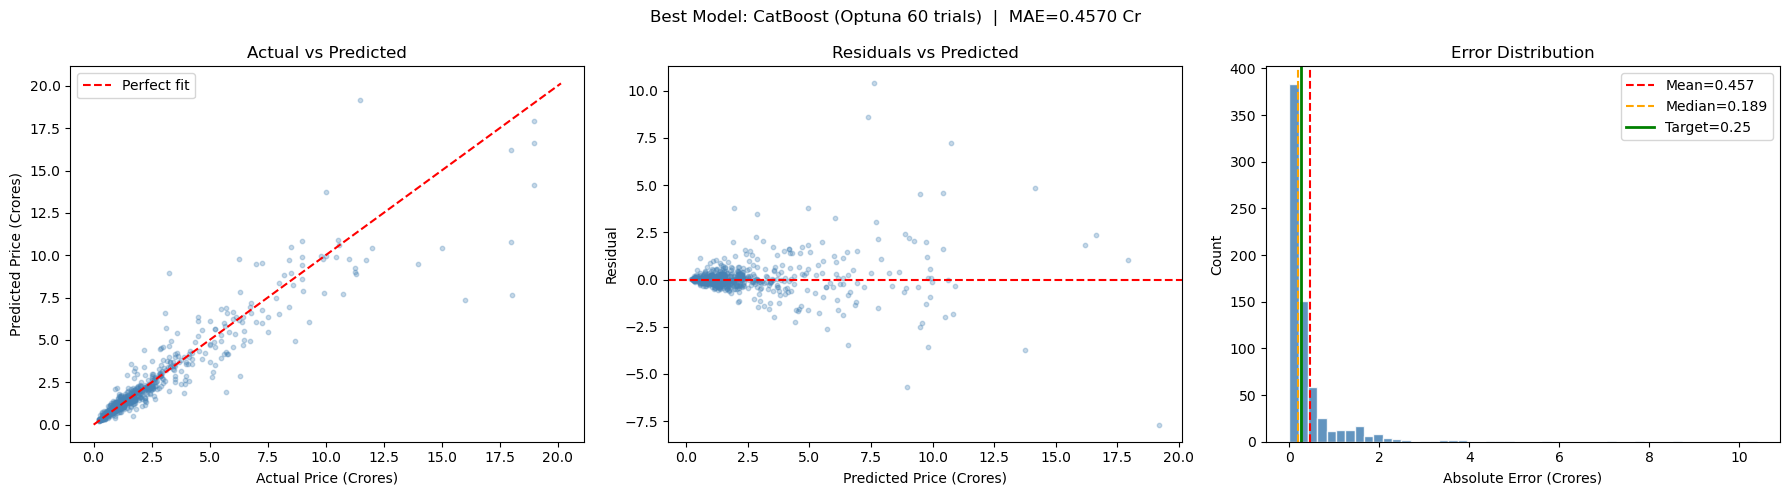

Error percentiles:
  P25: 0.0806 Cr
  P50: 0.1895 Cr
  P75: 0.4148 Cr
  P90: 1.1992 Cr
  P95: 1.7995 Cr

% predictions within 0.25 Cr : 60.2%
% predictions within 0.50 Cr : 79.6%


In [22]:
best_result = min(all_results, key=lambda r: r['mae'])
best_pipe   = best_result['pipeline']

best_pipe.fit(X_train, y_train)
y_pred_orig = np.expm1(best_pipe.predict(X_test))
y_true_orig = np.expm1(y_test)
errors      = np.abs(y_true_orig.values - y_pred_orig)
residuals   = y_true_orig.values - y_pred_orig

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Best Model: {best_result["name"]}  |  MAE={best_result["mae"]:.4f} Cr', fontsize=12)

# Actual vs Predicted
axes[0].scatter(y_true_orig, y_pred_orig, alpha=0.3, s=10, color='steelblue')
lim = max(y_true_orig.max(), y_pred_orig.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price (Crores)')
axes[0].set_ylabel('Predicted Price (Crores)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residuals
axes[1].scatter(y_pred_orig, residuals, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='r', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Price (Crores)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

# Error histogram
axes[2].hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].axvline(errors.mean(),     color='red',    linestyle='--', lw=1.5, label=f'Mean={errors.mean():.3f}')
axes[2].axvline(np.median(errors), color='orange', linestyle='--', lw=1.5, label=f'Median={np.median(errors):.3f}')
axes[2].axvline(0.25, color='green', linestyle='-',  lw=2,   label='Target=0.25')
axes[2].set_xlabel('Absolute Error (Crores)')
axes[2].set_ylabel('Count')
axes[2].set_title('Error Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig('error_analysis_final.png', dpi=120, bbox_inches='tight')
plt.show()

print('Error percentiles:')
for p in [25, 50, 75, 90, 95]:
    print(f'  P{p:2d}: {np.percentile(errors, p):.4f} Cr')
print(f'\n% predictions within 0.25 Cr : {(errors <= 0.25).mean()*100:.1f}%')
print(f'% predictions within 0.50 Cr : {(errors <= 0.50).mean()*100:.1f}%')

## 13. Feature Importance — Best Single Model

Exception ignored in: <function ResourceTracker.__del__ at 0x1028bdbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1111adbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


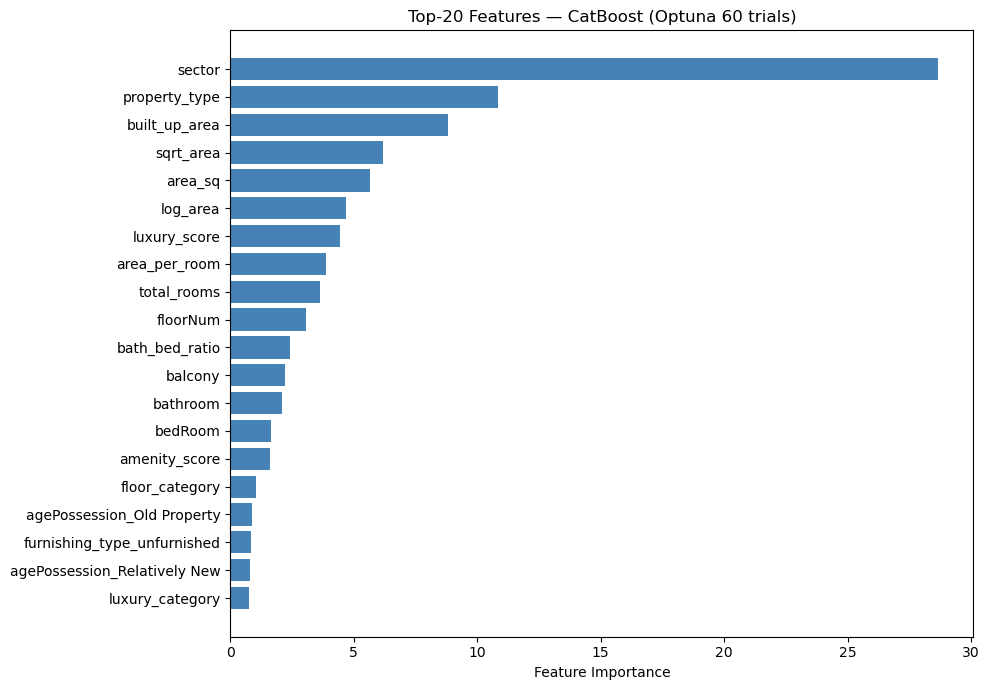

                     feature  importance
                      sector   28.655088
               property_type   10.853786
               built_up_area    8.810358
                   sqrt_area    6.162177
                     area_sq    5.675127
                    log_area    4.702771
                luxury_score    4.426594
               area_per_room    3.872078
                 total_rooms    3.648251
                    floorNum    3.081077
              bath_bed_ratio    2.421851
                     balcony    2.229754
                    bathroom    2.080242
                     bedRoom    1.644642
               amenity_score    1.596999
              floor_category    1.049053
  agePossession_Old Property    0.858798
 furnishing_type_unfurnished    0.818992
agePossession_Relatively New    0.796625
             luxury_category    0.748482


In [23]:
# Find best non-stacking model
single_results = [r for r in all_results if 'Stack' not in r['name']]
best_single    = min(single_results, key=lambda r: r['mae'])
pipe_single    = best_single['pipeline']
pipe_single.fit(X_train, y_train)

reg = pipe_single.named_steps['reg']
pre = pipe_single.named_steps['pre']

# Build feature names
try:
    ohe_names = list(pre.named_transformers_['ohe'].get_feature_names_out(OHE_COLS))
except:
    ohe_names = OHE_COLS
all_feat_names = NUM_COLS + ORD_COLS + ohe_names + TARGET_ENC_COLS

if hasattr(reg, 'feature_importances_'):
    importances = reg.feature_importances_
    n  = min(len(importances), len(all_feat_names))
    fi = pd.DataFrame({'feature': all_feat_names[:n], 'importance': importances[:n]})
    fi = fi.sort_values('importance', ascending=False)

    top20 = fi.head(20)
    plt.figure(figsize=(10, 7))
    plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
    plt.xlabel('Feature Importance')
    plt.title(f'Top-20 Features — {best_single["name"]}')
    plt.tight_layout()
    plt.savefig('feature_importance_final.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(fi.head(20).to_string(index=False))
else:
    print('Feature importances not available for this model type.')

## 14. Export Best Model

Re-fit on the **full dataset** before export (more data = lower generalization error).

In [24]:
best_export = best_result['pipeline']
best_export.fit(X, y_log)

with open('pipeline_final.pkl', 'wb') as f:
    pickle.dump(best_export, f)
with open('df_final.pkl', 'wb') as f:
    pickle.dump(X, f)

print(f'Exported: pipeline_final.pkl + df_final.pkl')
print(f'Model     : {best_result["name"]}')
print(f'Test MAE  : {best_result["mae"]:.4f} Crores')
print(f'Test RMSE : {best_result["rmse"]:.4f} Crores')
print(f'Test R²   : {best_result["r2"]:.4f}')

Exported: pipeline_final.pkl + df_final.pkl
Model     : CatBoost (Optuna 60 trials)
Test MAE  : 0.4570 Crores
Test RMSE : 1.0116 Crores
Test R²   : 0.8669


## 15. Sample Predictions

In [25]:
def predict_price(property_type, sector, bedRoom, bathroom, balcony,
                  agePossession, built_up_area, floorNum=5, luxury_score=50,
                  servant_room=0, store_room=0,
                  furnishing='unfurnished', luxury_cat='Low', floor_cat='Mid Floor',
                  study_room=0, pooja_room=0, others=0):
    row = {
        'property_type' : property_type,
        'sector'        : sector,
        'bedRoom'       : float(bedRoom),
        'bathroom'      : float(bathroom),
        'balcony'       : str(balcony),
        'agePossession' : agePossession,
        'built_up_area' : float(built_up_area),
        'servant room'  : float(servant_room),
        'store room'    : float(store_room),
        'furnishing_type': furnishing,
        'luxury_category': luxury_cat,
        'floor_category' : floor_cat,
        'floorNum'       : float(floorNum),
        'luxury_score'   : float(luxury_score),
        'study room'     : float(study_room),
        'pooja room'     : float(pooja_room),
        'others'         : float(others),
    }
    sample = pd.DataFrame([row])
    # FIX: Align to X columns BEFORE engineer_features, fill missing with mean/mode
    for c in X.columns:
        if c not in sample.columns:
            if X[c].dtype in [np.float64, np.int64, float, int]:
                sample[c] = X[c].mean()
            else:
                sample[c] = X[c].mode()[0]
    sample = sample[X.columns]
    sample = engineer_features(sample)
    return np.expm1(best_export.predict(sample))[0]


test_cases = [
    ('flat',  'sector 36',  3, 2, '2',  'New Property',    850, 2,  8,  0, 0, 'unfurnished',   'Low',    'Low Floor'),
    ('flat',  'sector 89',  2, 2, '2',  'New Property',   1226, 4,  38, 1, 0, 'unfurnished',   'Low',    'Mid Floor'),
    ('flat',  'sector 47',  4, 4, '3+', 'Relatively New', 2200, 8,  162,1, 1, 'semifurnished', 'High',   'Mid Floor'),
    ('house', 'sector 102', 4, 3, '3+', 'New Property',   2750, 0,  45, 0, 0, 'unfurnished',   'Low',    'Low Floor'),
    ('house', 'sector 43',  5, 6, '3+', 'Moderately Old', 5490, 0,  120,1, 1, 'unfurnished',   'Medium', 'Low Floor'),
]

print('Sample predictions:')
print(f'{"Type":6} {"Sector":15} {"BHK":4} {"Area":8} {"Predicted":>12}')
print('-' * 55)
for args in test_cases:
    pred = predict_price(*args)
    print(f'{args[0]:6} {args[1]:15} {args[2]}BHK  {args[6]:6} sqft → Rs {pred:6.2f} Cr')


## 16. If MAE is Still > 0.25 — Next Steps

If the stacked model is between 0.25–0.32, these additional techniques will push it further:

### A. Price-per-sqft Quantile Regression
Train a second model that predicts **price_per_sqft** (log-transformed), then
multiply by area. This decomposes the problem into a simpler sub-task.

### B. Post-processing: Clipping Luxury Outliers
The model over-predicts on ultra-luxury properties (>10 Cr). Training a separate
model for properties above the 95th percentile can help.

### C. More Optuna Trials
Increase to 200 trials for XGBoost and LightGBM. The TPE sampler continues improving.

### D. Tuned Ridge Meta-Learner
Replace `Ridge(alpha=1.0)` with `RidgeCV(alphas=[0.1, 1, 10, 100])` to auto-tune the meta-learner.

In [26]:
from sklearn.linear_model import RidgeCV

stacker_ridgecv = StackingRegressor(
    estimators=[
        ('xgb', XGBRegressor(**study_xgb.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
        ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
        ('cat', CatBoostRegressor(**study_cat.best_params, random_state=RANDOM_STATE, verbose=0)),
        ('et',  ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    final_estimator=RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]),
    cv=5,
    passthrough=False,  # FIX: no raw feature passthrough to meta-learner
    n_jobs=-1
)

stack_ridgecv_pipe = Pipeline([('pre', make_preprocessor()), ('reg', stacker_ridgecv)])

print('Fitting stacking with RidgeCV meta-learner (passthrough=False)...')
evaluate('Stacking (XGB+LGB+CB+ET → RidgeCV)', stack_ridgecv_pipe)


In [27]:
# Final sorted summary of all models
results_final = pd.DataFrame([
    {'Model': r['name'],
     'MAE':  round(r['mae'],  4),
     'RMSE': round(r['rmse'], 4),
     'R2':   round(r['r2'],   4),
     'MAPE%':round(r['mape'], 1),
     'CV_R2':round(r['cv_r2'],4)}
    for r in all_results
]).sort_values('MAE').reset_index(drop=True)

print('=== FINAL RESULTS (all models) ===')
print(results_final.to_string(index=False))

best = results_final.iloc[0]
print(f'\nBest: {best["Model"]}')
print(f'MAE={best["MAE"]:.4f}  RMSE={best["RMSE"]:.4f}  R2={best["R2"]:.4f}')
print(f'Target ≤0.25: {"ACHIEVED" if best["MAE"] <= 0.25 else "Not yet"}')

=== FINAL RESULTS (all models) ===
                                   Model    MAE   RMSE     R2  MAPE%  CV_R2
             CatBoost (Optuna 60 trials) 0.4570 1.0116 0.8669   18.4 0.8963
                       Extra Trees (200) 0.4633 1.0385 0.8597   18.9 0.8812
                   XGBoost default (300) 0.4675 1.0448 0.8580   19.2 0.8838
Stacking-Full (XGB+LGB+CB+ET+RF → Ridge) 0.4712 1.0914 0.8450   18.8 0.8981
           ExtraTrees (Optuna 50 trials) 0.4742 1.0534 0.8556   19.3 0.8835
      Stacking-Lite (XGB+LGB+CB → Ridge) 0.4753 1.0963 0.8436   18.9 0.8986
      Stacking (XGB+LGB+CB+ET → RidgeCV) 0.4759 1.0885 0.8458   19.0 0.8983
                     Random Forest (200) 0.4820 1.0821 0.8476   19.7 0.8835
                  CatBoost default (300) 0.4861 1.0864 0.8464   19.2 0.8953
            LightGBM (Optuna 100 trials) 0.4872 1.1570 0.8258   19.0 0.8982
                  LightGBM default (300) 0.4881 1.1794 0.8190   19.0 0.8934
             XGBoost (Optuna 100 trials) 0.4990 1.136